# Event-locked CTDS latent dynamics on Runyan PPC data

Fit a Cell-Type Dynamical System (CTDS) to one Potter / Bassi / Runyan 2024
session (`FU1-00 / 2022-03-17`) using the inhibitory population activity events
from `D_onsets_v2.mat` as trials. Each event provides a 501-frame window aligned
to either a SOM-led or PV-led inhibitory burst. After fitting we look at how
the inferred E and I latents evolve around event onsets and compare SOM vs PV
conditions.

Cell-type convention (per the paper): `cellid == 0` (GCaMP-only) → putative
pyramidal / E; `cellid == 1` (mCherry) → SOM; `cellid == 2` (tdTomato) → PV.
We pool SOM and PV into a single inhibitory group for this fit.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import mannwhitneyu

import jax
import jax.numpy as jnp

from pillow_lab_rotation.jax_ctds import CTDSJax
import pillow_lab_rotation.dataio as dataio

from importlib import reload

In [2]:
DATA_ROOT = Path('../data/runyan_data')
MOUSE = 'FU1-00'
DATE = '2022-03-17'
SESSION_DIR = DATA_ROOT / MOUSE / DATE

In [3]:
reload(dataio)
dataset = dataio.RunyanSession(MOUSE, DATE)

In [4]:
obs_evt = dataset.obs_evt
is_som = dataset.is_som
is_pv = dataset.is_pv
Ne = dataset.Ne
Ni = dataset.Ni
N = dataset.N

# Plot event locked activity for each cell type

In [5]:
from scipy.stats import sem
def evt_mean(
        arr: np.ndarray,
        cell_type_mask: np.ndarray,
        cell_slice: slice
) -> tuple[np.ndarray, np.ndarray]:
    pop = arr[cell_type_mask, :, cell_slice, 0].mean(axis=2) # (n_evt_in_group, T)
    return pop.mean(0), sem(pop, axis=0)

mean_exc_som, sem_exc_som = evt_mean(obs_evt, is_som, slice(0, Ne))
mean_exc_pv, sem_exc_pv = evt_mean(obs_evt, is_pv, slice(0, Ne))

mean_inh_som, sem_inh_som = evt_mean(obs_evt, is_som, slice(Ne, N))
mean_inh_pv, sem_inh_pv = evt_mean(obs_evt, is_pv, slice(Ne, N))

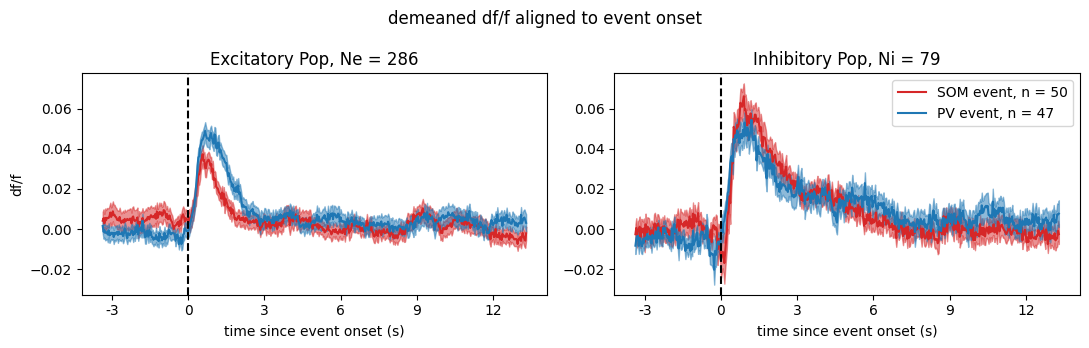

In [6]:
fig = plt.figure(figsize=(11, 3.5))

ax1 = fig.add_subplot(121)
ax1.plot(mean_exc_som, c='C3')
ax1.fill_between(
    np.arange(len(mean_exc_som)),
    mean_exc_som - sem_exc_som,
    mean_exc_som + sem_exc_som,
    alpha=0.5,
    color='C3',
    label='SOM event'
)

ax1.plot(mean_exc_pv, label='SOM event')
ax1.fill_between(
    np.arange(len(mean_exc_pv)),
    mean_exc_pv - sem_exc_pv,
    mean_exc_pv + sem_exc_pv,
    alpha=0.5,
    color='C0',
    label='PV event'
)
ax1.set_title(f'Excitatory Pop, Ne = {Ne}')
ax1.set_ylabel('df/f')
ax1.axvline(101, ls='--', c='k')
ax1.set_xticks([11 + 90 * i for i in range(6)], [i * 3 for i in range(-1, 5)])
ax1.set_xlabel('time since event onset (s)')



ax2 = fig.add_subplot(122)
ax2.sharex(ax1)
ax2.sharey(ax1)
ax2.plot(mean_inh_som, c='C3', label=f'SOM event, n = {dataset.n_som_evt}')
ax2.fill_between(
    np.arange(len(mean_inh_som)),
    mean_inh_som - sem_inh_som,
    mean_inh_som + sem_inh_som,
    alpha=0.5,
    color='C3'
)

ax2.plot(mean_inh_pv, label=f'PV event, n = {dataset.n_pv_evt}')
ax2.fill_between(
    np.arange(len(mean_inh_pv)),
    mean_inh_pv - sem_inh_pv,
    mean_inh_pv + sem_inh_pv,
    alpha=0.5,
    color='C0'
)
ax2.set_title(f'Inhibitory Pop, Ni = {Ni}')
ax2.axvline(101, ls='--', c='k')
ax2.set_xlabel('time since event onset (s)')


plt.legend()
fig.suptitle('demeaned df/f aligned to event onset')
fig.tight_layout()

## Fit CTDS

`CTDSJax(De, Di, Ne, Ni)` enforces:

- Dale's law on `A`: E columns ≥ 0, I columns ≤ 0 (off-diagonals).
- Block-diagonal non-negative `C`: E neurons load only E latents, I neurons
  load only I latents.
- Diagonal `R`.

We use a small latent budget — `De=10` E latents and `Di=5` I latents. Random
init is enough at this scale; switch to `init_params(obs_evt_jax)` for
EIRNN/NMF init if EM gets stuck.

In [7]:
De, Di = 3, 3

obs_evt_jax = jnp.asarray(obs_evt)
model = CTDSJax(De=De, Di=Di, Ne=Ne, Ni=Ni, key=jax.random.PRNGKey(10))
model.fit(obs_evt_jax, verbose=True, max_iter=30, init='random')

Iteration 0: LL = -352.218140
Iteration 1: LL = 157.113525
Iteration 2: LL = 163.386810
Iteration 3: LL = 169.622147
Iteration 4: LL = 171.727188
Iteration 5: LL = 172.474243
Iteration 6: LL = 172.810562
Iteration 7: LL = 173.015411
Iteration 8: LL = 173.168198
Iteration 9: LL = 173.294373
Iteration 10: LL = 173.401855
Iteration 11: LL = 173.491730
Iteration 12: LL = 173.567719
Iteration 13: LL = 173.632401
Iteration 14: LL = 173.687881
Iteration 15: LL = 173.735550
Iteration 16: LL = 173.776505
Iteration 17: LL = 173.811996
Iteration 18: LL = 173.842667
Iteration 19: LL = 173.869125
Iteration 20: LL = 173.892227
Iteration 21: LL = 173.912598
Iteration 22: LL = 173.930634
Iteration 23: LL = 173.946335
Iteration 24: LL = 173.960526
Iteration 25: LL = 173.973312
Iteration 26: LL = 173.985077
Iteration 27: LL = 173.995819
Iteration 28: LL = 174.005783
Iteration 29: LL = 174.015121
Iteration 30: LL = 174.023743


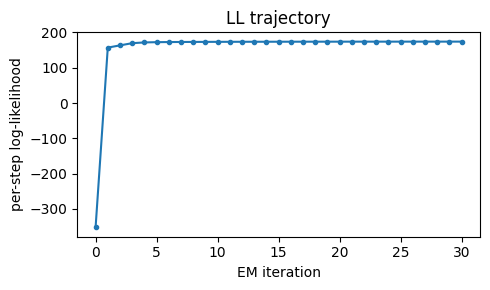

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(model.ll_history, marker='o', ms=3)
ax.set_xlabel('EM iteration')
ax.set_ylabel('per-step log-likelihood')
ax.set_title('LL trajectory')
fig.tight_layout()

## Inspect fit

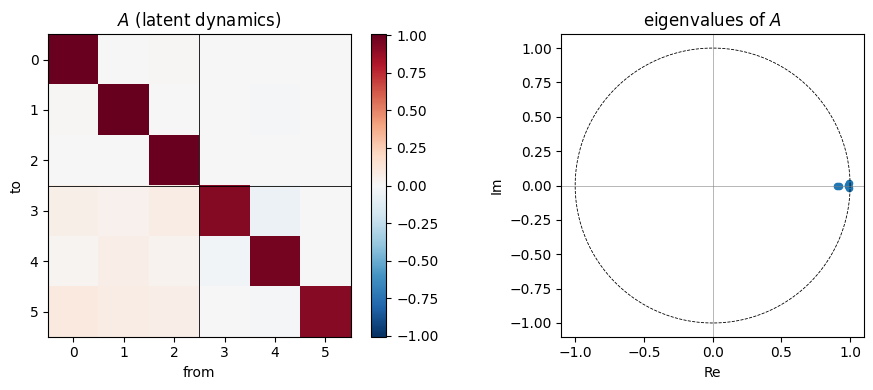

In [9]:
A = np.asarray(model.A)
C = np.asarray(model.C)
R = np.asarray(model.R)
Q = np.asarray(model.Q)
m_evt = np.asarray(model.m).squeeze(-1)                  # (n_evt, T_evt, D_lat)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = np.abs(A).max()
imA = axes[0].imshow(A, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
axes[0].axhline(De - 0.5, color='k', lw=0.6)
axes[0].axvline(De - 0.5, color='k', lw=0.6)
axes[0].set_title(r'$A$ (latent dynamics)')
axes[0].set_xlabel('from'); axes[0].set_ylabel('to')
fig.colorbar(imA, ax=axes[0], fraction=0.046)

eigvals = np.linalg.eigvals(A)
theta = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(np.cos(theta), np.sin(theta), 'k--', lw=0.6)
axes[1].scatter(eigvals.real, eigvals.imag, s=20)
axes[1].axhline(0, color='gray', lw=0.4); axes[1].axvline(0, color='gray', lw=0.4)
axes[1].set_aspect('equal')
axes[1].set_xlabel('Re'); axes[1].set_ylabel('Im')
axes[1].set_title('eigenvalues of $A$')
fig.tight_layout()

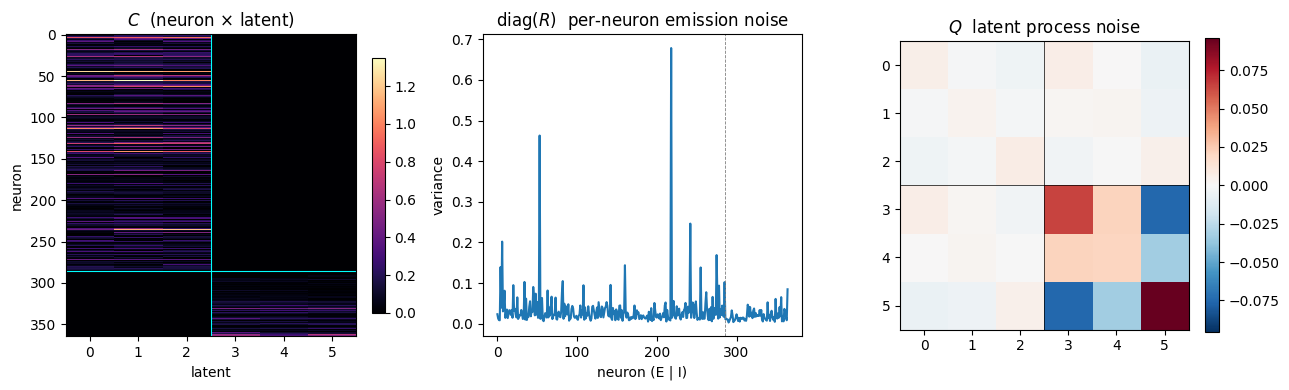

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

imC = axes[0].imshow(C, cmap='magma', aspect='auto', interpolation='none')
axes[0].axhline(Ne - 0.5, color='cyan', lw=0.8)
axes[0].axvline(De - 0.5, color='cyan', lw=0.8)
axes[0].set_title(r'$C$  (neuron $\times$ latent)')
axes[0].set_xlabel('latent'); axes[0].set_ylabel('neuron')
fig.colorbar(imC, ax=axes[0], fraction=0.04)

axes[1].plot(np.diag(R))
axes[1].axvline(Ne - 0.5, color='gray', ls='--', lw=0.6)
axes[1].set_title(r'$\mathrm{diag}(R)$  per-neuron emission noise')
axes[1].set_xlabel('neuron (E | I)')
axes[1].set_ylabel('variance')

vmaxQ = np.abs(Q).max()
imQ = axes[2].imshow(Q, cmap='RdBu_r', vmin=-vmaxQ, vmax=vmaxQ)
axes[2].axhline(De - 0.5, color='k', lw=0.5); axes[2].axvline(De - 0.5, color='k', lw=0.5)
axes[2].set_title(r'$Q$  latent process noise')
fig.colorbar(imQ, ax=axes[2], fraction=0.046)

fig.tight_layout()

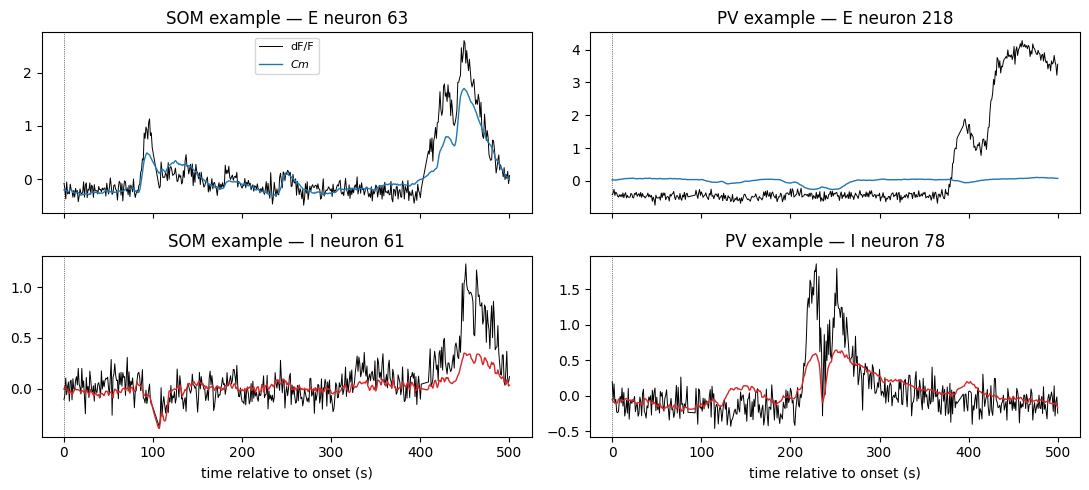

In [11]:
# Single-event reconstruction y_hat = C m for one example SOM event and one PV event.
ex_som = int(np.where(is_som)[0][0])
ex_pv  = int(np.where(is_pv)[0][0])

fig, axes = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
for col, (label, ev_i) in enumerate([('SOM example', ex_som), ('PV example', ex_pv)]):
    y_obs = obs_evt[ev_i, :, :, 0]
    y_hat = m_evt[ev_i] @ C.T

    e_pick = int(np.argmax(np.abs(y_obs[:, :Ne]).max(0)))
    i_pick = Ne + int(np.argmax(np.abs(y_obs[:, Ne:]).max(0)))
    # e_pick = int(np.random.randint(0, Ne))
    # i_pick = int(np.random.randint(Ne, N))

    axes[0, col].plot(y_obs[:, e_pick], color='k', lw=0.7, label='dF/F')
    axes[0, col].plot(y_hat[:, e_pick], color='C0', lw=1.0, label=r'$Cm$')
    axes[0, col].axvline(0, color='k', ls=':', lw=0.5)
    axes[0, col].set_title(f'{label} — E neuron {e_pick}')

    axes[1, col].plot(y_obs[:, i_pick], color='k', lw=0.7)
    axes[1, col].plot(y_hat[:, i_pick], color='C3', lw=1.0)
    axes[1, col].axvline(0, color='k', ls=':', lw=0.5)
    axes[1, col].set_title(f'{label} — I neuron {i_pick - Ne}')
    axes[1, col].set_xlabel('time relative to onset (s)')

axes[0, 0].legend(fontsize=8)
fig.tight_layout()

## Event-locked latent dynamics

The headline question: do the inferred E and I latents differentiate SOM-led
vs PV-led inhibitory bursts? For each latent we compute the average trajectory
across SOM events and across PV events.

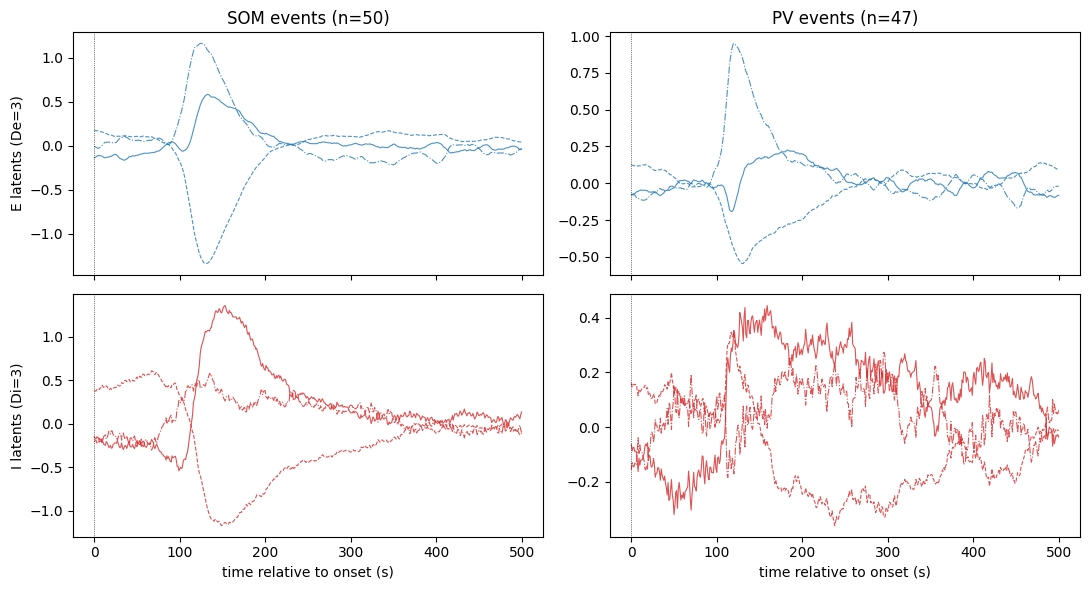

In [12]:
def latent_avg(m_arr, mask):
    sel = m_arr[mask]                                    # (n_evt, T, D)
    return sel.mean(0), sel.std(0) / np.sqrt(sel.shape[0])

mu_som, sem_som = latent_avg(m_evt, is_som)
mu_pv,  sem_pv  = latent_avg(m_evt, is_pv)

# All E and I latents overlaid, one panel per (population, condition)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
linestyles = ['-', '--', '-.']
for d in range(De):
    axes[0, 0].plot(mu_som[:, d], color='C0', lw=0.8, alpha=0.8, ls=linestyles[d])
    axes[0, 1].plot(mu_pv[:, d],  color='C0', lw=0.8, alpha=0.8, ls=linestyles[d])
for d in range(Di):
    axes[1, 0].plot(mu_som[:, De + d], color='C3', lw=0.8, alpha=0.8, ls=linestyles[d])
    axes[1, 1].plot(mu_pv[:, De + d],  color='C3', lw=0.8, alpha=0.8, ls=linestyles[d])

axes[0, 0].set_title(f'SOM events (n={is_som.sum()})')
axes[0, 1].set_title(f'PV events (n={is_pv.sum()})')
axes[0, 0].set_ylabel(f'E latents (De={De})')
axes[1, 0].set_ylabel(f'I latents (Di={Di})')
for ax in axes.flat:
    ax.axvline(0, color='k', ls=':', lw=0.5)
for ax in axes[-1]:
    ax.set_xlabel('time relative to onset (s)')
fig.tight_layout()

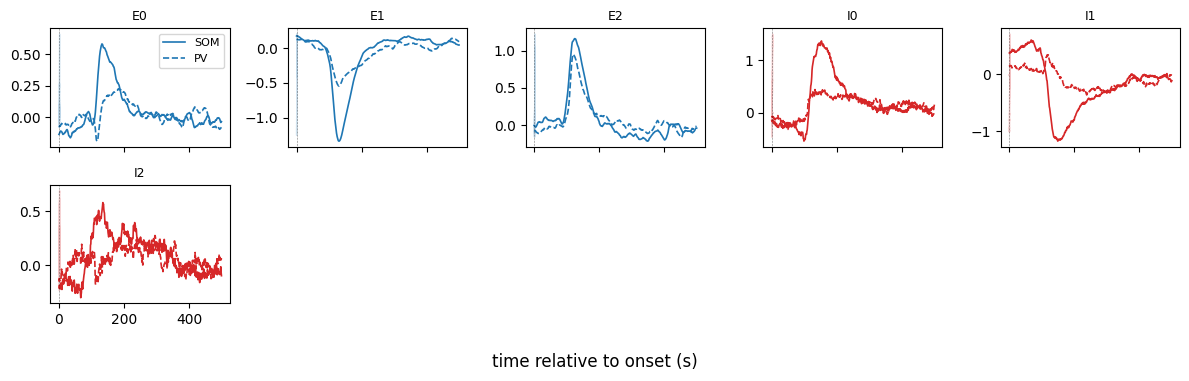

In [55]:
# Per-latent SOM vs PV overlay — does each latent dimension distinguish
# the two event types? Solid = SOM, dashed = PV; shaded = SEM across events.
n_cols = 5
n_rows = int(np.ceil((De + Di) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 1.9 * n_rows),
                         sharex=True)
axes = axes.flatten()
for d in range(De + Di):
    is_E = d < De
    color = 'C0' if is_E else 'C3'
    label = f'{"E" if is_E else "I"}{d if is_E else d - De}'
    axes[d].plot( mu_som[:, d], color=color, lw=1.2, label='SOM')
    axes[d].plot( mu_pv[:, d],  color=color, lw=1.2, ls='--', label='PV')
    axes[d].fill_between(
                         mu_som[:, d] - sem_som[:, d], mu_som[:, d] + sem_som[:, d],
                         color=color, alpha=0.2)
    axes[d].fill_between(
                         mu_pv[:, d] - sem_pv[:, d], mu_pv[:, d] + sem_pv[:, d],
                         color=color, alpha=0.1)
    axes[d].axvline(0, color='k', ls=':', lw=0.4)
    axes[d].set_title(label, fontsize=9)
for d in range(De + Di, len(axes)):
    axes[d].set_visible(False)
axes[0].legend(fontsize=8)
fig.supxlabel('time relative to onset (s)')
fig.tight_layout()

## E vs I reconstruction quality

Per-neuron variance explained by the smoothed reconstruction `y_hat = C m`
across all event trials.

E (n=286): mean R² = 0.101, median = 0.040
I (n=79): mean R² = 0.149, median = 0.075
Mann-Whitney U=10121, p=1.57e-01


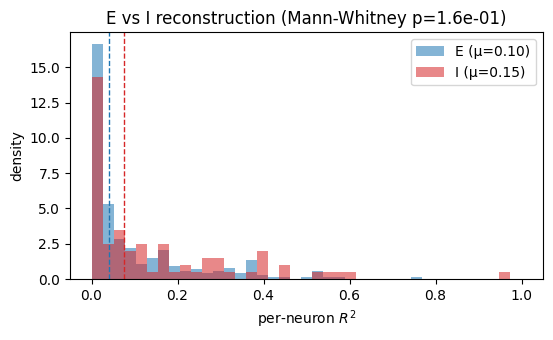

In [56]:
y_obs_all = obs_evt.squeeze(-1).reshape(-1, N)
y_hat_all = (m_evt @ C.T).reshape(-1, N)
resid = y_obs_all - y_hat_all
r2 = 1.0 - resid.var(0) / y_obs_all.var(0)               # (N,)

r2_E = r2[:Ne]
r2_I = r2[Ne:]
u, p = mannwhitneyu(r2_E, r2_I, alternative='two-sided')

print(f'E (n={Ne}): mean R² = {r2_E.mean():.3f}, median = {np.median(r2_E):.3f}')
print(f'I (n={Ni}): mean R² = {r2_I.mean():.3f}, median = {np.median(r2_I):.3f}')
print(f'Mann-Whitney U={u:.0f}, p={p:.2e}')

fig, ax = plt.subplots(figsize=(5.5, 3.5))
bins = np.linspace(min(0, r2.min()), 1.0, 40)
ax.hist(r2_E, bins=bins, alpha=0.55, color='C0', density=True,
        label=f'E (μ={r2_E.mean():.2f})')
ax.hist(r2_I, bins=bins, alpha=0.55, color='C3', density=True,
        label=f'I (μ={r2_I.mean():.2f})')
ax.axvline(np.median(r2_E), color='C0', ls='--', lw=1)
ax.axvline(np.median(r2_I), color='C3', ls='--', lw=1)
ax.set_xlabel(r'per-neuron $R^2$')
ax.set_ylabel('density')
ax.set_title(f'E vs I reconstruction (Mann-Whitney p={p:.1e})')
ax.legend()
fig.tight_layout()